In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [ ]:
_catalog = 'AE'
_catalog = "Bielszowice_2022_2023"
_catalog = "Bielszowice.Katalog.SOS sc 314"
_catalog = "Bielszowice.Katalog.SOS sc 514"
_catalog = "Catalog_jaguars_aftershocks_fault"
_catalog = "Catalog_jaguars_aftershocks_full_verified"
_catalog = 'Catalog_jaguars_aftershocks_stope'
_catalog = 'Catalog_jaguars_blast_2007_12_15to16'
_catalog = 'Catalog_jaguars_blast_2008_04_30to05_01'
_catalog = 'Catalog_jaguars_blast_2008_05_10to11'
_catalog = 'Catalog_jaguars_scaling'
_catalog = 'Cooper_Basin_Catalog_HAB_1_2003_Reprocessed'
_catalog = 'Cooper_Basin_Catalog_HAB_1_2005'
_catalog = 'Cooper_Basin_Catalog_HAB_4'
_catalog = 'COTTON_VALLEY_Catalog'
_catalog = 'CZORSZTYN_catalog'
_catalog = 'CZORSZTYN_relocation_TRMLOC_catalog'
_catalog = 'Gazli_Catalog_3L'
_catalog = 'Gazli_Catalog_10L'
_catalog = 'Gazli_Catalog_Local'
_catalog = 'GISOS_catalog'
_catalog = 'Lacq_Catalog_1L'
_catalog = 'Lacq_Catalog_3L'
_catalog = 'Lacq_Catalog_10L'
_catalog = 'Lacq_Catalog_Local'
_catalog = 'LaiChau_local'
_catalog = 'Monteynard_Catalog_3L'
_catalog = 'Monteynard_Catalog_10L'
_catalog = 'Ruda_004_catalog'
_catalog = 'Ruda_005_catalog'
_catalog = 'Ruda_252_catalog'
_catalog = 'Ruda_310_catalog'
_catalog = 'Ruda_502a_catalog'
_catalog = 'Ruda_506a_catalog'
_catalog = 'Ruda_829_catalog'
_catalog = 'USCB_catalog'
_catalog = 'USCB_Ziemowit_catalog'

In [208]:
_catalog = 'USCB_Ziemowit_catalog'

core_name = f'{_catalog}_100ev.txt'
#directory = f'{_catalog}_catalog'
directory = f'episodes'
path = f'data/SSD_DC_new/{directory}/'
clean_name = os.path.splitext(core_name)[0]


df1 = pd.read_csv(f"{path}SSD_{core_name}", sep='\s+', header=None, 
                  names=['Time', 'Mag', 'Log10_SSD', 'CF1_V', 'CF2_V'])

df2 = pd.read_csv(f"{path}DC_{core_name}", sep='\s+', header=None, 
                  names=['Time', 'DC'])

# df = pd.merge(df1, df2, on='Time', how='outer')

# żeby uniknąć dwóch magnitud - bierzemy te z ssd pliku
df = pd.merge(df1, df2[['Time', 'DC']], on='Time', how='inner')

df['Datetime'] = pd.to_datetime(df['Time'] - 719529, unit='D')
#df['Log10_Wynik'] = np.log10(df['SSD'])

df

,Time,Mag,Log10_SSD,CF1_V,CF2_V,DC,Datetime
0,736797.84,0.47,4.300048,4.208892,4.375351,0.675289,2017-04-12 20:09:35.999997184
1,736797.84,0.63,4.303885,4.212729,4.379188,0.675289,2017-04-12 20:09:35.999997184
2,736797.87,0.42,4.302730,4.211574,4.378032,0.674485,2017-04-12 20:52:47.999999488
3,736797.89,0.51,4.294284,4.203128,4.369586,0.674839,2017-04-12 21:21:36.000001280
4,736797.91,0.11,4.294454,4.203298,4.369756,0.679207,2017-04-12 21:50:24.000002816
...,...,...,...,...,...,...,...
25201,738156.16,0.79,4.305186,4.214030,4.380489,0.648384,2020-12-31 03:50:24.000002816
25202,738156.33,1.11,4.310484,4.219328,4.385787,0.652212,2020-12-31 07:55:11.999996416
25203,738156.37,0.95,4.315378,4.224222,4.390681,0.650548,2020-12-31 08:52:47.999999488
25204,738156.60,0.26,4.311153,4.219997,4.386455,0.655726,2020-12-31 14:23:59.999997952


In [209]:
output_dir = f'wykresy/{_catalog}/'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Utworzono nowy folder: {output_dir}")

Wykres został zapisany w: wykresy/USCB_Ziemowit_catalog/plot_USCB_Ziemowit_catalog_100ev.png


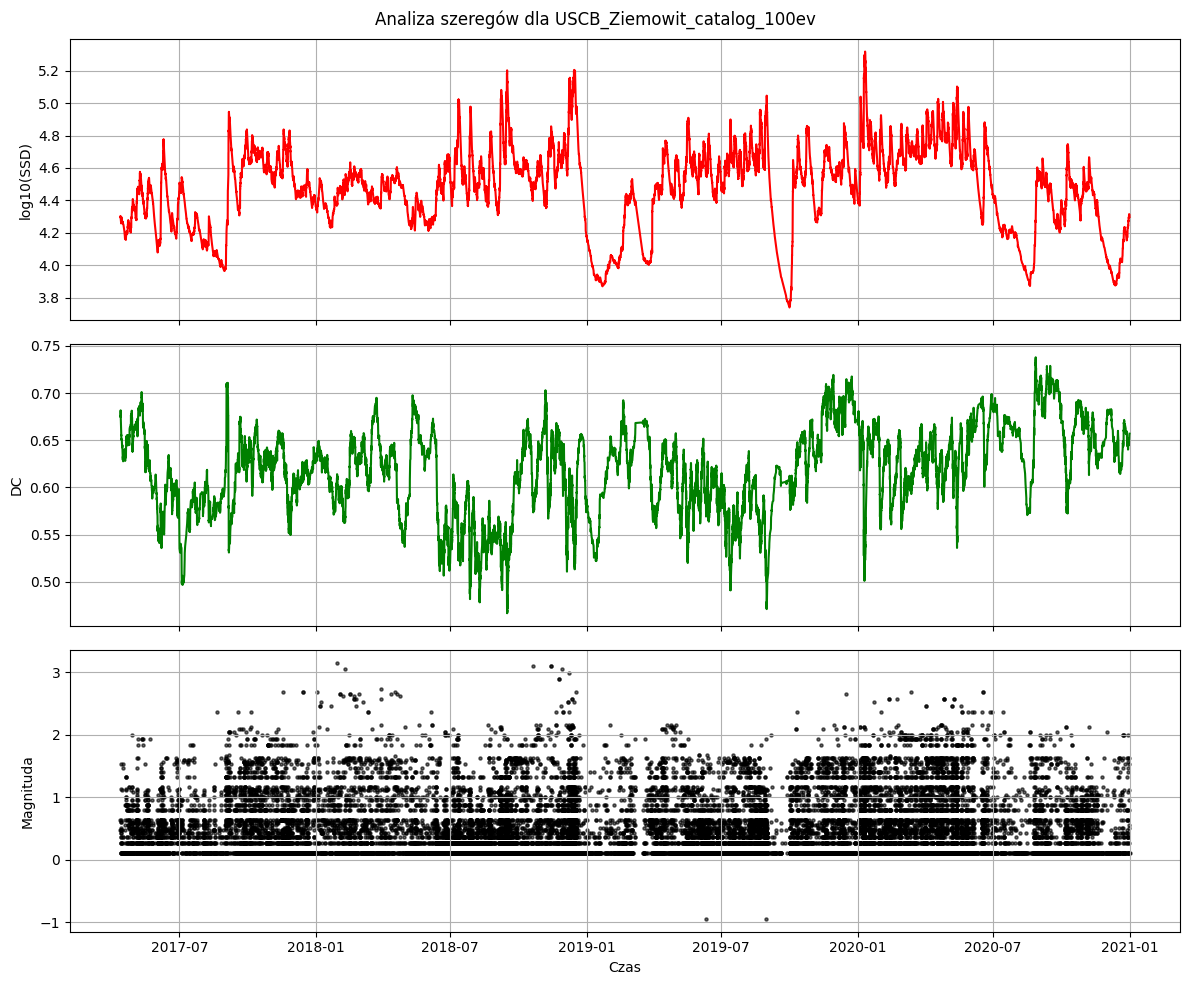

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax1.plot('Datetime', 'Log10_SSD', data=df, color='red')
ax1.set_ylabel('log10(SSD)')
ax1.grid(True)

ax2.plot('Datetime', 'DC', data=df, color='green')
ax2.set_ylabel('DC')
ax2.grid(True)

ax3.scatter(df['Datetime'], df['Mag'], color='black', s=5, alpha=0.6)
ax3.set_ylabel('Magnituda')
ax3.set_xlabel('Czas')
ax3.grid(True)

plt.suptitle(f"Analiza szeregów dla {clean_name}")
plt.tight_layout()

save_path = os.path.join(output_dir, f"plot_{clean_name}.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Wykres został zapisany w: {save_path}")

plt.show()

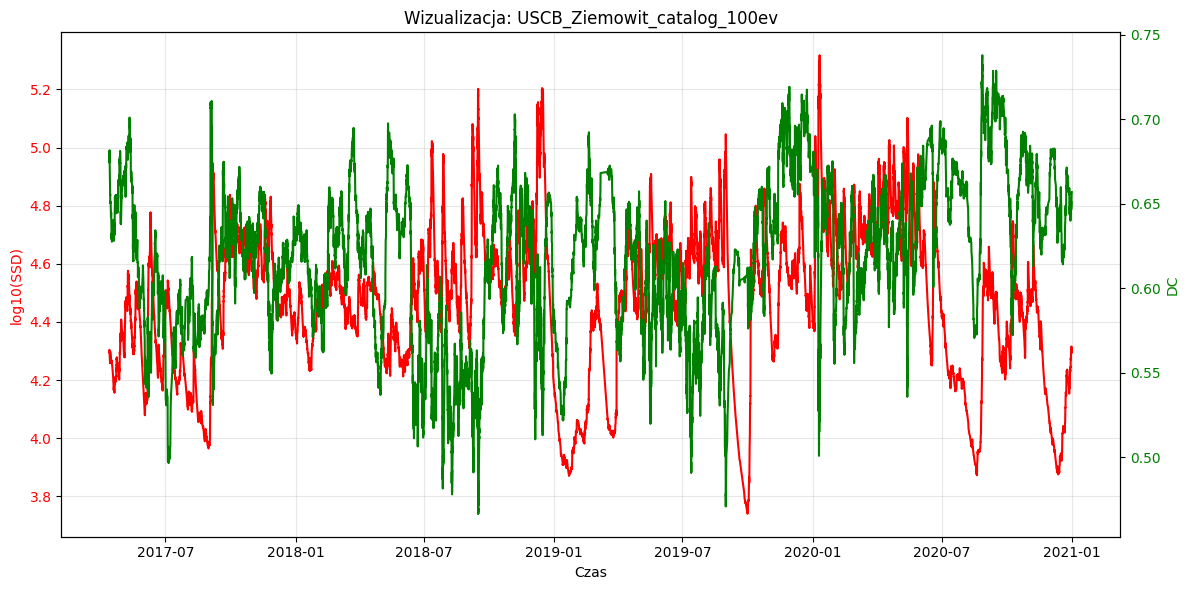

In [211]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Czas')
ax1.set_ylabel('log10(SSD)', color='red')
ax1.plot('Datetime', 'Log10_SSD', data=df, color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx() 
ax2.set_ylabel('DC', color='green')
ax2.plot('Datetime', 'DC', data=df, color='green', label='DC')
ax2.tick_params(axis='y', labelcolor='green')

plt.title(f"Wizualizacja: {clean_name}")
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


In [212]:
# to csv
seeking_phase_fir = "szukanie_faz"
if not os.path.exists(seeking_phase_fir):
    os.makedirs(seeking_phase_fir)
    print(f"Utworzono nowy folder: {seeking_phase_fir}")

csv_file_path = os.path.join(seeking_phase_fir, f"dane_{clean_name}.csv")
df.to_csv(csv_file_path, index=False)

df

,Time,Mag,Log10_SSD,CF1_V,CF2_V,DC,Datetime
0,736797.84,0.47,4.300048,4.208892,4.375351,0.675289,2017-04-12 20:09:35.999997184
1,736797.84,0.63,4.303885,4.212729,4.379188,0.675289,2017-04-12 20:09:35.999997184
2,736797.87,0.42,4.302730,4.211574,4.378032,0.674485,2017-04-12 20:52:47.999999488
3,736797.89,0.51,4.294284,4.203128,4.369586,0.674839,2017-04-12 21:21:36.000001280
4,736797.91,0.11,4.294454,4.203298,4.369756,0.679207,2017-04-12 21:50:24.000002816
...,...,...,...,...,...,...,...
25201,738156.16,0.79,4.305186,4.214030,4.380489,0.648384,2020-12-31 03:50:24.000002816
25202,738156.33,1.11,4.310484,4.219328,4.385787,0.652212,2020-12-31 07:55:11.999996416
25203,738156.37,0.95,4.315378,4.224222,4.390681,0.650548,2020-12-31 08:52:47.999999488
25204,738156.60,0.26,4.311153,4.219997,4.386455,0.655726,2020-12-31 14:23:59.999997952
